In [120]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_community.llms import Ollama
from langchain_huggingface import HuggingFaceEmbeddings
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from tqdm import tqdm

# Carregando o dataset

In [2]:
# Specify the file path
file_path = "inflação/data/human/human_conciliado_220.csv"

# Load the dataset
df = pd.read_csv(
    file_path,
    sep='|', 
    parse_dates=['Date'],  # Converte a coluna Date para o tipo datetime
    dayfirst=True,          # Interpreta datas no formato DD/MM/YYYY
    encoding='utf-8'
)

# Display the first few rows of the dataset
print(df.head())

        Date  Model  Grade                                           Sentence
0 2009-09-02  human     -1  No médio prazo, o risco advém dos efeitos, cum...
1 2011-11-30  human     -1  Os preços livres aumentaram 7, 24% no período ...
2 2009-10-21  human      0  Nesse contexto, após um período de flexibiliza...
3 2013-04-17  human     -1  Considerada a série observada, o Nuci apresent...
4 2002-11-20  human     -1  Dados preliminares da Fecomércio mostram que o...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      220 non-null    datetime64[ns]
 1   Model     220 non-null    object        
 2   Grade     220 non-null    int64         
 3   Sentence  220 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 7.0+ KB


# Carregando LLM

In [4]:
inicio = time.time()
llm = Ollama(model="gemma4:e4b", temperature=0)  # ajuste modelo/parametros conforme necessário
prompt = "Olá modelo como estás?"
resp_text = llm.invoke(prompt)
fim = time.time()
duracao = fim - inicio
print(f'duracao: {duracao}\n{resp_text}\n\n')

/tmp/ipykernel_1791792/1081730878.py:2: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  llm = Ollama(model="gemma4:e4b", temperature=0)  # ajuste modelo/parametros conforme necessário


duracao: 8.754426956176758
Olá! Estou bem, obrigado/a por perguntar. 😊

Como posso ajudar você hoje? E você, como está?




# Carregar o modelo de embeddings

In [5]:
# Gerar embeddings usando modelo HuggingFace
embeddings = HuggingFaceEmbeddings(model_name="Qwen/Qwen3-Embedding-0.6B")

In [25]:
df['embedding'] = embeddings.embed_documents(df['Sentence'].tolist())

In [94]:
MODEL = "gemma4:e4b"

PROMPT = """
DEFINIÇÃO DE OTIMISMO:
Ocorre quando as projeções indicam que a inflação ficará abaixo da meta ou dentro do intervalo de tolerância com folga. 
Isso pode sinalizar que o Banco Central vê espaço para reduzir juros ou manter uma política monetária mais acomodatícia. 

DEFINIÇÃO DE PESSIMISMO:
Ocorre quando as projeções apontam para inflação acima da meta ou próxima do teto do intervalo de tolerância. 
Isso sugere preocupação com pressões inflacionárias e pode justificar uma política monetária mais restritiva.

AVALIE A FRASE COMO
O para OTIMISTA
N para NEUTRA
P para PESSIMISTA
NÃO DEIXE DE RESPONDER E SUA RESPOSTA DEVE SER APENAS UMA DAS 3 LETRAS, SEM QUALQUER OUTRO TEXTO
SE ACHAR A FRASE AMBIGUA, OU NÃO SOUBER CLASSIFICAR RESPONDA COM N

Utilize os exemplos abaixo para guiar sua avaliação:
#exemplos#

A FRASE A SER ANALISADA É:
"""

GRADE_MAP = {'O': 1, 'N': 0, 'P': -1}
REVERSE_GRADE_MAP = {1: 'O', 0: 'N', -1: 'P'}


# Dynamic Few Shot

O Dynamic Few-Shot Prompting é uma técnica avançada de engenharia de prompt que seleciona e injeta automaticamente os exemplos mais relevantes para a IA a cada nova requisição, em vez de utilizar um conjunto fixo de demonstrações. Utilizando busca por similaridade semântica (geralmente via banco de dados vetoriais e embeddings), o sistema identifica no repositório de dados os cenários mais próximos do texto enviado pelo usuário e constrói um contexto personalizado em tempo de execução. Essa abordagem reduz drasticamente o consumo de tokens, diminui custos e eleva a precisão do modelo, pois fornece referências altamente contextualizadas sem sobrecarregar a janela de contexto.

- Liu, J., Shen, D., Zhang, Y., Dolan, B., Carin, L., & Chen, W. (2022). What Makes Good In-Context Examples for GPT-3? Proceedings of the 1st Workshop on Learning with Natural Language Supervision (ACL).
> Relevância: Artigo pioneiro que provou formalmente que utilizar k-Nearest Neighbors ($k$-NN) e dense embeddings para selecionar exemplos dinâmicos por similaridade semântica supera significativamente a seleção aleatória ou estática de exemplos.


In [ ]:
# A função retorna k exemplos por classe mais próximos da frase de entrada, com base na similaridade do embedding.
def build_few_shot_messages(df, actual, k_per_class=2):
    # remover de existing as sentenças que são duplicadas, mantendo apenas a primeira ocorrência
    df_nonrep = df.drop_duplicates(subset='Sentence', keep='first').copy()
    df_nonrep = df_nonrep[df_nonrep['Sentence'] != actual]
    # embedding da frase de entrada
    actual_embedding = embeddings.embed_query(actual)
    # Calculando a similaridade de forma vetorizada
    sentence_embeddings = np.array(df_nonrep['embedding'].tolist())
    similarities = cosine_similarity([actual_embedding], sentence_embeddings)[0]
    df_nonrep['similarity'] = similarities
    # Selecionar top-k por grupo
    selected_examples = (
        df_nonrep.sort_values(by=['Grade', 'similarity'], ascending=[True, False])
        .groupby('Grade', as_index=False)
        .head(k_per_class)
        .sort_values(by='similarity', ascending=False)
    )
    # Formatar a string de retorno para o prompt
    examples_text = ""
    for _, row in selected_examples.iterrows():
        examples_text += f"Frase: \"{row['Sentence']}\"\nClassificação: {REVERSE_GRADE_MAP[row['Grade']]}\n\n"
    return examples_text.strip()

In [101]:
sentence = 'No período posterior à reunião do Copom de janeiro, a curva de juros reduziu sua inclinação, com elevação das taxas de curto prazo e recuo das taxas de prazos superiores a um ano.'
few_shot_messages = build_few_shot_messages(df, sentence)
print(few_shot_messages)

Frase: "A decisão do Copom de reduzir a meta para a taxa Selic em 50   na reunião de junho, a continuidade do movimento de valorização do real frente ao dólar e a divulgação, no início de julho, de índices de inflação corrente dentro do intervalo das projeções contribuíram para o recuo das taxas de prazo de até um ano."
Classificação: O

Frase: "A elevação da meta para a Taxa Selic nas duas últimas reuniões do COPOM e o resgate líquido de LTN explicam a redução da dívida prefixada desde o início de março."
Classificação: N

Frase: "O Copom ressalta que não faz sentido, diante do quadro de normalização macroeconômica que o país vem logrando consolidar, inferir de forma mecânica que um ritmo mais moderado de reduções dos juros corresponda a uma avaliação negativa sobre o comportamento futuro da inflação, ou que dele deva resultar pessimismo a respeito da trajetória futura do nível de atividade."
Classificação: O

Frase: "No cenário com trajetórias para as taxas Selic e de câmbio extraída

In [103]:
df['Prediction'] = None
df

,Date,Model,Grade,Sentence,fewshot-gemma4:e4b,embedding,Prediction
0,2009-09-02,human,-1,"No médio prazo, o risco advém dos efeitos, cum...",-1,"[-0.0914243534207344, 0.0282067209482193, -0.0...",None
1,2011-11-30,human,-1,"Os preços livres aumentaram 7, 24% no período ...",-1,"[-0.07298122346401215, 0.035013504326343536, -...",None
2,2009-10-21,human,0,"Nesse contexto, após um período de flexibiliza...",0,"[-0.025030523538589478, -0.010209095664322376,...",None
3,2013-04-17,human,-1,"Considerada a série observada, o Nuci apresent...",0,"[-0.06018374115228653, -0.0029133267235010862,...",None
4,2002-11-20,human,-1,Dados preliminares da Fecomércio mostram que o...,0,"[-0.03592279925942421, 0.0010930614080280066, ...",None
...,...,...,...,...,...,...,...
215,2019-10-30,human,0,As estimativas e projeções de curto prazo indi...,-1,"[-0.06084345653653145, 0.014659847132861614, -...",None
216,2004-07-21,human,-1,O núcleo de inflação para o IPCA calculado por...,1,"[-0.02012086659669876, -0.00950214546173811, -...",None
217,2008-12-10,human,-1,"Em síntese, ainda não se consolidou o processo...",0,"[-0.0003755490470211953, 0.032327160239219666,...",None
218,2019-03-20,human,0,Todos os membros do Comitê voltaram a enfatiza...,1,"[-0.07414636760950089, 0.015188509598374367, -...",None


In [119]:
for i in range(5):
    pred_col = 'k'+str(i+1)
    df[pred_col] = None

In [124]:
for i in range(5):
    pred_col = 'k'+str(i+1)
    #df[pred_col] = None

    for idx, r in tqdm(df.iterrows(), total=len(df)):
        if r[pred_col] in [0, 1, -1]: continue
        sentence = r['Sentence']
        #tqdm.write(i, idx, end=' ')
        few_shot_messages = build_few_shot_messages(df, r['Sentence'], i+1)
        actual_prompt = PROMPT.replace('#exemplos#', few_shot_messages) + sentence
        #break
        resp_text = llm.invoke(actual_prompt)
        resp_text = resp_text.strip('AI: ')
        #tqdm.write(f"{i}  {idx}: {resp_text}")
        #r['Prediction'] = resp_text
        df.loc[idx, pred_col] = GRADE_MAP[resp_text]
        #break

100%|██████████| 220/220 [21:43<00:00,  5.93s/it]


In [125]:
df.head()

,Date,Model,Grade,Sentence,fewshot-gemma4:e4b,embedding,Prediction,k1,k2,k3,k4,k5
0,2009-09-02,human,-1,"No médio prazo, o risco advém dos efeitos, cum...",-1,"[-0.0914243534207344, 0.0282067209482193, -0.0...",-1,-1,-1,-1,-1,-1
1,2011-11-30,human,-1,"Os preços livres aumentaram 7, 24% no período ...",-1,"[-0.07298122346401215, 0.035013504326343536, -...",0,0,0,0,-1,-1
2,2009-10-21,human,0,"Nesse contexto, após um período de flexibiliza...",0,"[-0.025030523538589478, -0.010209095664322376,...",0,0,0,0,0,0
3,2013-04-17,human,-1,"Considerada a série observada, o Nuci apresent...",0,"[-0.06018374115228653, -0.0029133267235010862,...",0,0,0,0,0,0
4,2002-11-20,human,-1,Dados preliminares da Fecomércio mostram que o...,0,"[-0.03592279925942421, 0.0010930614080280066, ...",0,0,0,0,0,0


In [106]:
df.tail()

,Date,Model,Grade,Sentence,fewshot-gemma4:e4b,embedding,Prediction
215,2019-10-30,human,0,As estimativas e projeções de curto prazo indi...,-1,"[-0.06084345653653145, 0.014659847132861614, -...",0
216,2004-07-21,human,-1,O núcleo de inflação para o IPCA calculado por...,1,"[-0.02012086659669876, -0.00950214546173811, -...",-1
217,2008-12-10,human,-1,"Em síntese, ainda não se consolidou o processo...",0,"[-0.0003755490470211953, 0.032327160239219666,...",0
218,2019-03-20,human,0,Todos os membros do Comitê voltaram a enfatiza...,1,"[-0.07414636760950089, 0.015188509598374367, -...",1
219,2010-03-17,human,0,No período posterior à reunião do Copom de jan...,0,"[-0.04054640606045723, 0.0078722033649683, -0....",0


In [ ]:
#df.rename(columns={'Prediction': 'fewshot-gemma4:e4b'}, inplace=True)
#df.head()

,Date,Model,Grade,Sentence,fewshot-gemma4:e4b
0,2009-09-02,human,-1,"No médio prazo, o risco advém dos efeitos, cum...",-1
1,2011-11-30,human,-1,"Os preços livres aumentaram 7, 24% no período ...",-1
2,2009-10-21,human,0,"Nesse contexto, após um período de flexibiliza...",0
3,2013-04-17,human,-1,"Considerada a série observada, o Nuci apresent...",0
4,2002-11-20,human,-1,Dados preliminares da Fecomércio mostram que o...,0


In [131]:
y_true = df['Grade'].astype(str)
for i in range(5):
    print(f"Resultados para {i+1} exemplos por classe:")
    pred_col = 'k'+str(i+1)
    y_pred = df[pred_col].astype(str)
    print(classification_report(y_true, y_pred))

Resultados para 1 exemplos por classe:
              precision    recall  f1-score   support

          -1       0.69      0.61      0.64        61
           0       0.67      0.76      0.71       111
           1       0.65      0.54      0.59        48

    accuracy                           0.67       220
   macro avg       0.67      0.63      0.65       220
weighted avg       0.67      0.67      0.66       220

Resultados para 2 exemplos por classe:
              precision    recall  f1-score   support

          -1       0.75      0.69      0.72        61
           0       0.73      0.81      0.77       111
           1       0.68      0.58      0.63        48

    accuracy                           0.73       220
   macro avg       0.72      0.69      0.71       220
weighted avg       0.73      0.73      0.72       220

Resultados para 3 exemplos por classe:
              precision    recall  f1-score   support

          -1       0.75      0.64      0.69        61
           0

Resultados para 1 exemplos por classe:


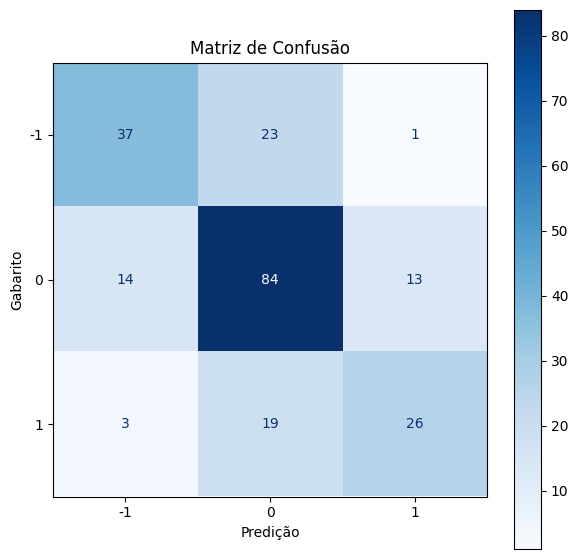

Resultados para 2 exemplos por classe:


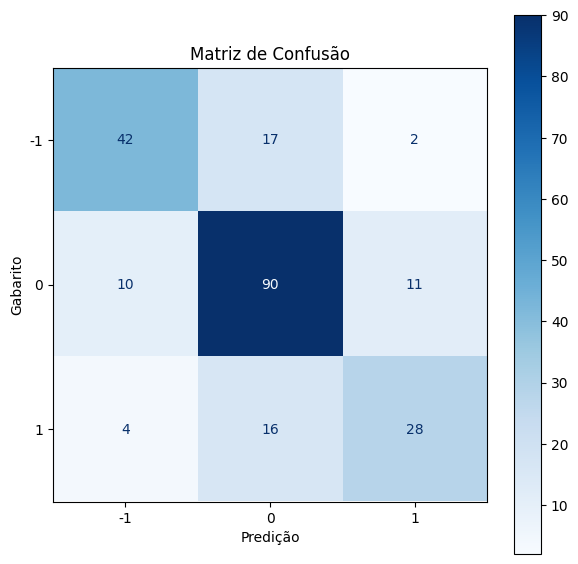

Resultados para 3 exemplos por classe:


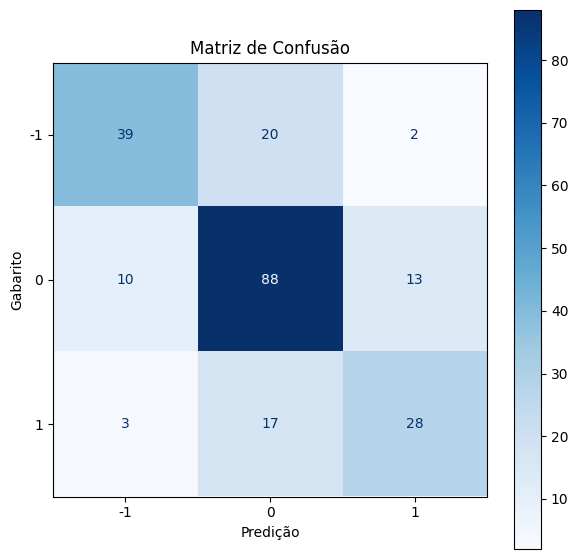

Resultados para 4 exemplos por classe:


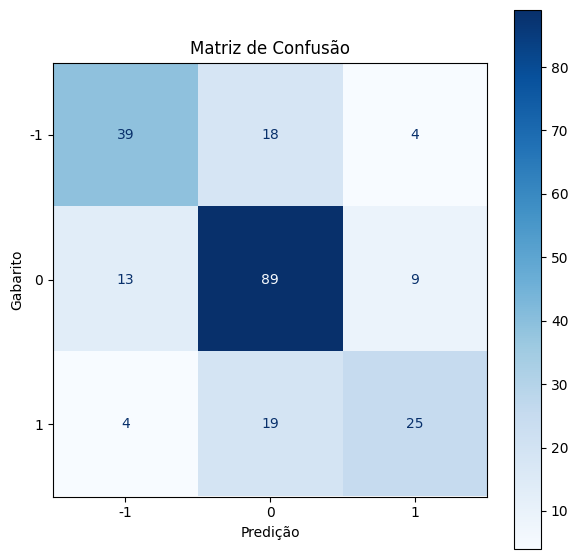

Resultados para 5 exemplos por classe:


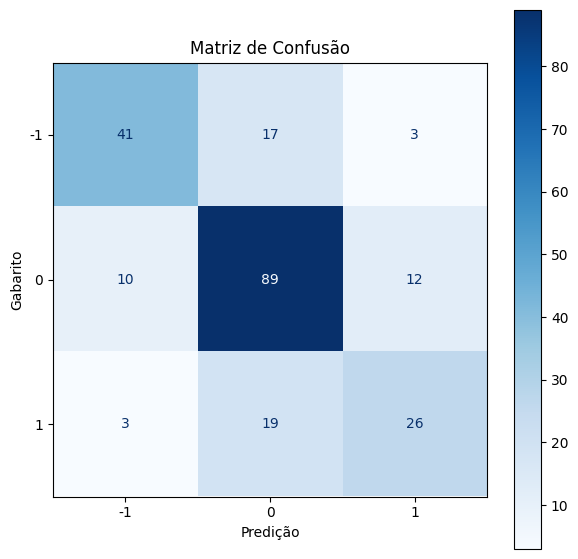

In [130]:
y_true = df['Grade'].astype(str)
for i in range(5):
    print(f"Resultados para {i+1} exemplos por classe:")
    pred_col = 'k'+str(i+1)
    y_pred = df[pred_col].astype(str)
    # Plota a matriz diretamente com Matplotlib
    fig, ax = plt.subplots(figsize=(7, 7))

    ConfusionMatrixDisplay.from_predictions(
        y_true, 
        y_pred, 
        cmap=plt.cm.Blues, 
        ax=ax,
        colorbar=True
    )

    plt.title('Matriz de Confusão')
    plt.xlabel('Predição')
    plt.ylabel('Gabarito')
    plt.show()
